# Extreme Gradient Boosting

In this file I implement an XGBoost regression model to forecast next-day WTI log returns using macroeconomic data from FRED-MD. I explicitly design the pipeline to avoid data leakage, align macro variables to oil trading days, and use lagged features. I import NumPy and pandas for data manipulation, TimeSeriesSplit to preserve chronological order during validation, and XGBRegressor to model nonlinear relationships. The structure mirrors my other models so that comparison across Elastic Net, VAR, and XGBoost is consistent.

# Imports

In [15]:
# ============================================================
# XGBoost Forecasting for WTI Futures (Next-Day Log Returns)
# ============================================================
# This script implements a nonlinear gradient boosting model
# to forecast next-day WTI crude oil log returns.
#
# Design principles:
# - Use FRED-MD macroeconomic data
# - Align macro variables strictly to oil trading days
# - Apply anti-leakage macro shifting
# - Use 30-day lagged feature window
# - Perform time-series cross-validation
# - Apply early stopping to control overfitting
# ============================================================

from __future__ import annotations  # Ensures forward type hint compatibility

from pathlib import Path            # For file path handling
import numpy as np                  # Numerical computations
import pandas as pd                 # Data manipulation
import pickle                       # Model persistence

from abc import ABC, abstractmethod  # For abstract base class
from sklearn.model_selection import TimeSeriesSplit  # Time-aware CV
from xgboost import XGBRegressor    # Gradient boosting model


# BaseForecastModel
In this block, I define an abstract base class that all forecasting models must inherit from. I require every model to implement fit, predict, evaluate, save, and load. This enforces structural consistency across Elastic Net, VAR, and XGBoost.

I do this because I want a unified modeling framework. If every model follows the same interface, I can easily swap models, compare results, and evaluate them in a standardized way. This is especially important in my VIP project because I am comparing linear and nonlinear approaches.

Even though this block does not directly affect model performance, it improves clarity, reproducibility, and research structure. It ensures that my modeling pipeline is organized and consistent.

In [16]:
# ============================================================
# Base Forecast Model
# ============================================================

class BaseForecastModel(ABC):
    """
    Abstract base class for all forecasting models.

    This class enforces a consistent interface across different
    model types such as Elastic Net, VAR, and XGBoost.

    Attributes:
        task_type (str): Type of predictive task, e.g. "regression".
    """

    def __init__(self, task_type: str):
        """
        Initialize the base model.

        Args:
            task_type (str): The type of task. For this project,
                this will always be "regression" since we predict returns.
        """
        self.task_type = task_type


    @abstractmethod
    def fit(self, *args, **kwargs):
        """
        Train the forecasting model.

        Subclasses must implement this method.
        """
        pass


    @abstractmethod
    def predict(self, X):
        """
        Generate predictions from the trained model.

        Args:
            X (pd.DataFrame or np.ndarray): Input feature matrix.

        Returns:
            np.ndarray: Model predictions.
        """
        pass


    @abstractmethod
    def evaluate(self, X, y):
        """
        Evaluate model performance on a dataset.

        Args:
            X (pd.DataFrame or np.ndarray): Input feature matrix.
            y (pd.Series or np.ndarray): True target values.

        Returns:
            dict: Dictionary of evaluation metrics.
        """
        pass


    @abstractmethod
    def save(self, path: str):
        """
        Save the trained model to disk.

        Args:
            path (str): File path to save the model.
        """
        pass


    @abstractmethod
    def load(self, path: str):
        """
        Load a previously saved model from disk.

        Args:
            path (str): File path of the saved model.
        """
        pass


# Metrics
In this block, I define the evaluation metrics used to assess forecasting performance.

RMSE measures the square root of average squared error. It penalizes larger errors more heavily and is sensitive to volatility spikes. This is useful in return forecasting because large mistakes matter.

MAE measures the average absolute error. It is more robust to outliers and gives a direct interpretation of average prediction error magnitude.

R-squared measures how much variance in returns the model explains relative to predicting the mean. In daily return forecasting, I expect R-squared to be very small because returns are noisy.

Directional accuracy measures how often the model correctly predicts whether returns are positive or negative. This metric is particularly relevant for financial forecasting because correctly predicting direction can have economic value even when R-squared is near zero.

Using all four metrics gives a more complete view of performance rather than relying on a single statistic.

In [17]:
# ============================================================
# Metrics
# ============================================================

def rmse(y, yhat):
    """
    Compute Root Mean Squared Error.

    RMSE penalizes larger errors more heavily due to squaring.
    It is commonly used for regression performance evaluation.

    Args:
        y (array-like): True target values.
        yhat (array-like): Predicted values.

    Returns:
        float: Root mean squared error.
    """
    y = np.asarray(y, dtype=float)      # Ensure numeric array
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


def mae(y, yhat):
    """
    Compute Mean Absolute Error.

    MAE measures the average absolute deviation between
    predictions and true values.

    Args:
        y (array-like): True target values.
        yhat (array-like): Predicted values.

    Returns:
        float: Mean absolute error.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.abs(y - yhat)))


def r2(y, yhat):
    """
    Compute R-squared.

    R2 measures the proportion of variance explained
    by the model relative to predicting the mean.

    Args:
        y (array-like): True target values.
        yhat (array-like): Predicted values.

    Returns:
        float: R-squared value.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    ss_tot = np.sum((y - y.mean()) ** 2)   # Total variance
    ss_res = np.sum((y - yhat) ** 2)       # Residual variance

    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def directional_accuracy(y, yhat):
    """
    Compute directional accuracy.

    Measures the percentage of times the model correctly
    predicts the sign of returns.

    Args:
        y (array-like): True target returns.
        yhat (array-like): Predicted returns.

    Returns:
        float: Proportion of correct sign predictions.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    return float(np.mean(np.sign(y) == np.sign(yhat)))


# Data Helpers (Strict Leakage Control)
In this block, I define the core data preparation utilities that ensure the modeling pipeline is clean and leakage-free.

First, I load the monthly macroeconomic data from FRED-MD. I convert the date column to a proper datetime index and keep only the selected macro variables that I identified as relevant to oil markets. This reduces unnecessary dimensionality and keeps the feature space controlled.

Next, I load the daily WTI crude oil price series. I keep the trading-day index exactly as it appears in the data. I do not create artificial weekend rows because that would introduce synthetic returns.

Then, I create lagged features. Since I am forecasting next-day returns, I must only use past information. For each macro variable and momentum feature, I create 30 lagged versions. This allows the model to capture delayed macro effects and short-term momentum dynamics.

Finally, I define the prediction target as the next-day log return. Log returns are standard in finance because they are additive over time and statistically more stable than raw price differences.

This entire block is critical because it determines whether the model sees future information. If this block is incorrect, the model would produce artificially inflated performance. Strict chronological ordering and lagging ensure proper time-series forecasting.

In [18]:
# ============================================================
# Data Helpers (STRICT leakage control)
# ============================================================

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """
    Load monthly FRED-MD macroeconomic data.

    This function reads the macro dataset, parses the date column,
    sorts chronologically, and keeps only selected features.

    Args:
        path (Path): File path to the FRED-MD CSV file.
        features (list[str]): List of macro variables to keep.

    Returns:
        pd.DataFrame: Monthly macro data indexed by date.
    """
    # Read CSV and rename the date column
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})

    # Convert to datetime and sort
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    # Keep only requested features
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]

    # Warn if any requested features are missing
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")

    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """
    Load WTI crude oil futures price data.

    Args:
        path (Path): File path to price CSV.

    Returns:
        pd.Series: Daily oil price series indexed by trading days.
    """
    px = pd.read_csv(path, parse_dates=["Date"])

    # Set Date as index and sort
    s = px.set_index("Date")["Price"].sort_index()

    return s


def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """
    Create lagged versions of each feature.

    For each column in X, this function creates L lagged features:
    lag01 (t-1), lag02 (t-2), ..., lagL (t-L).

    Args:
        X (pd.DataFrame): Input feature matrix.
        L (int): Number of lags.

    Returns:
        pd.DataFrame: Lagged feature matrix with missing rows removed.
    """
    # Create lagged copies of each feature
    lagged = [
        X.shift(l).add_suffix(f"_lag{l:02d}")
        for l in range(1, L + 1)
    ]

    # Concatenate all lagged features horizontally
    return pd.concat(lagged, axis=1).dropna()


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """
    Compute future log returns as prediction target.

    Target is defined as:
        y_t = log(P_{t+h}) - log(P_t)

    Args:
        price (pd.Series): Oil price series.
        horizon (int): Forecast horizon in days.

    Returns:
        pd.Series: Future log return series.
    """
    price = price.astype(float)

    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")


# Trading-Day Aligned Dataset Builder
In this block, I construct the full modeling dataset while strictly preserving time structure.

First, I load the monthly macroeconomic variables. I then apply an anti-leakage shift so that macro values labeled for month m only become available at the beginning of month m+1. This reflects real-world data publication delays and prevents the model from seeing future macro information.

Next, I load the daily WTI futures price data. I align macro variables to oil trading days only. I forward fill macro values because macro data is monthly while oil prices are daily. This ensures that each trading day has the latest available macro information without inventing artificial days.

I then add daily log returns as a momentum feature. This allows the model to capture short-term price persistence.

After that, I create 30 lagged versions of both macro variables and daily returns. This allows the model to capture delayed macro effects and dynamic price behavior.

I construct the target as the next-day log return and align it carefully with the feature matrix to avoid misalignment.

Finally, I split the dataset chronologically into training, validation, and test sets. I never shuffle the data because this is a time-series forecasting problem. The validation set is used for hyperparameter tuning, and the test set is reserved for final out-of-sample evaluation.

This function is critical because it ensures the model sees only information that would have been available at each point in time. Any mistake here would invalidate the results.

In [19]:
# ============================================================
# Trading-Day Aligned Dataset Builder
# ============================================================

def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """
    Build the full modeling dataset with strict time alignment.

    This function:
    1. Loads macro and price data.
    2. Applies anti-leakage macro shifting.
    3. Aligns macro variables to oil trading days.
    4. Creates lagged features.
    5. Computes the future return target.
    6. Splits data chronologically into train, validation, and test sets.

    Args:
        macro_file (Path): Path to FRED-MD macro dataset.
        price_file (Path): Path to WTI price dataset.
        features (list[str]): Selected macro features.
        lookback (int): Number of lag days.
        horizon (int): Forecast horizon in days.
        train_end (str): End date of training set.
        val_end (str): End date of validation set.

    Returns:
        tuple:
            X_train, y_train,
            X_val, y_val,
            X_test, y_test
    """

    # ---------------------------
    # Load macro monthly data
    # ---------------------------
    macro_m = load_macro_monthly(macro_file, features)

    # Apply anti-leakage shift:
    # Macro value for month m becomes available at month m+1.
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # ---------------------------
    # Load oil prices (trading days only)
    # ---------------------------
    price = load_price(price_file)

    # Align macro strictly onto trading-day index
    # Forward fill because macro is monthly and price is daily
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Combine macro and price
    base = macro_d.join(price, how="inner").dropna()

    # ---------------------------
    # Add daily momentum feature
    # ---------------------------
    # Uses only past price information
    base["ret_1d"] = np.log(base["Price"]).diff()

    # ---------------------------
    # Create lagged features
    # ---------------------------
    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)

    # Combine macro and price lags
    X = X_macro.join(X_price).dropna()

    # ---------------------------
    # Create target
    # ---------------------------
    y = make_target(base["Price"], horizon=horizon)

    # Align target and feature indices
    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]

    # ---------------------------
    # Chronological split
    # ---------------------------
    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train = X.index <= train_end
    val = (X.index > train_end) & (X.index <= val_end)
    test = X.index > val_end

    return (
        X.loc[train], y.loc[train],
        X.loc[val],   y.loc[val],
        X.loc[test],  y.loc[test],
    )


# XGBoost Model
In this class, I implement the full XGBoost forecasting model.

I initialize the model with hyperparameters that control tree complexity and regularization. Since daily oil returns are noisy, I restrict depth and use subsampling to prevent overfitting. I use early stopping so that boosting stops when validation error stops improving.

In the fit method, I perform time-series cross validation using TimeSeriesSplit. This ensures that training always occurs on past data and validation on future data. For each hyperparameter combination, I compute average validation RMSE and select the best set. This prevents overfitting to a single split.

After selecting the best parameters, I retrain the model on the full training dataset. If a separate validation dataset is provided, I use it again for early stopping to refine the number of trees.

The predict method generates next-day return forecasts. The evaluate method computes RMSE, MAE, R2, and directional accuracy. Directional accuracy is especially important in financial return prediction.

The feature_importance method extracts importance based on gain and maps internal feature indices back to real feature names so that I can interpret which macro variables and lags drive predictions.

Finally, the save and load methods allow the trained model to be stored and reused later.

In [20]:
# ============================================================
# XGBoost Forecast Model
# ============================================================

class XGBoostForecastModel(BaseForecastModel):
    """
    XGBoost regression model for forecasting next-day WTI log returns.

    This model:
        - Uses gradient boosted decision trees.
        - Performs time-series cross-validation.
        - Applies early stopping to reduce overfitting.
        - Tunes hyperparameters using validation RMSE.
    """

    def __init__(
        self,
        n_splits: int = 5,
        num_boost_round: int = 3000,
        early_stopping_rounds: int = 50,
        random_state: int = 42,
        n_jobs: int = -1,
    ):
        """
        Initialize the XGBoost forecasting model.

        Args:
            n_splits (int): Number of TimeSeriesSplit folds.
            num_boost_round (int): Maximum number of boosting trees.
            early_stopping_rounds (int): Stop training if validation
                error does not improve for this many rounds.
            random_state (int): Random seed for reproducibility.
            n_jobs (int): Number of parallel CPU threads.
        """
        super().__init__("regression")

        # Cross-validation configuration
        self.n_splits = n_splits

        # Maximum number of trees allowed
        self.num_boost_round = num_boost_round

        # Controls early stopping behavior
        self.early_stopping_rounds = early_stopping_rounds

        # Reproducibility
        self.random_state = random_state

        # Parallel execution
        self.n_jobs = n_jobs

        # Hyperparameter grid controlling tree complexity
        self.param_grid = [
            {
                "max_depth": 3,
                "learning_rate": 0.03,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "min_child_weight": 1,
            },
            {
                "max_depth": 4,
                "learning_rate": 0.03,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "min_child_weight": 1,
            },
            {
                "max_depth": 5,
                "learning_rate": 0.05,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "min_child_weight": 3,
            },
        ]

        # Placeholders
        self.model = None
        self.best_params_ = None
        self.cv_results_ = []
        self.feature_names_ = None
        self.eval_results_ = None


    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Train the XGBoost model using time-series cross validation.

        Args:
            X_train (pd.DataFrame): Training feature matrix.
            y_train (pd.Series): Training target.
            X_val (pd.DataFrame, optional): Validation features.
            y_val (pd.Series, optional): Validation target.

        Returns:
            self
        """

        # Store feature names for interpretability later
        self.feature_names_ = list(X_train.columns)

        # Convert to numpy arrays for XGBoost
        X = X_train.values
        y = y_train.values

        # Time-aware cross validation
        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        best_rmse = np.inf
        best_params = None

        # ---------------------------------------------------
        # Hyperparameter search across time-series folds
        # ---------------------------------------------------
        for params in self.param_grid:

            fold_rmses = []

            for tr_idx, va_idx in tscv.split(X):

                # Chronological train-validation split
                Xtr, Xva = X[tr_idx], X[va_idx]
                ytr, yva = y[tr_idx], y[va_idx]

                # Initialize model with current parameter set
                model = XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=self.num_boost_round,
                    tree_method="hist",
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    early_stopping_rounds=self.early_stopping_rounds,
                    **params
                )

                # Train with early stopping on fold validation data
                model.fit(
                    Xtr, ytr,
                    eval_set=[(Xva, yva)],
                    verbose=False
                )

                # Compute validation error
                preds = model.predict(Xva)
                fold_rmses.append(rmse(yva, preds))

            mean_rmse = np.mean(fold_rmses)

            self.cv_results_.append({
                "params": params,
                "rmse": mean_rmse
            })

            # Keep best performing parameter set
            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_params = params

        # Store best hyperparameters
        self.best_params_ = {**best_params, "cv_rmse": best_rmse}

        # ---------------------------------------------------
        # Final model training on full training set
        # ---------------------------------------------------
        self.model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=self.num_boost_round,
            tree_method="hist",
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            early_stopping_rounds=self.early_stopping_rounds,
            **best_params
        )

        # Use separate validation set for early stopping if provided
        if X_val is not None and y_val is not None:

            self.model.fit(
                X_train.values, y_train.values,
                eval_set=[
                    (X_train.values, y_train.values),   # training loss
                    (X_val.values, y_val.values)        # validation loss
                ],
                verbose=False
            )

            # Store training history
            self.eval_results_ = self.model.evals_result()

        else:

            self.model.fit(X_train.values, y_train.values)

        return self


    def predict(self, X):
        """
        Generate return forecasts.

        Args:
            X (pd.DataFrame): Feature matrix.

        Returns:
            np.ndarray: Predicted next-day log returns.
        """
        return self.model.predict(X.values)


    def evaluate(self, X, y):
        """
        Evaluate model performance.

        Args:
            X (pd.DataFrame): Feature matrix.
            y (pd.Series): True returns.

        Returns:
            dict: Performance metrics.
        """
        preds = self.predict(X)

        return {
            "rmse": rmse(y.values, preds),
            "mae": mae(y.values, preds),
            "r2": r2(y.values, preds),
            "directional_acc": directional_accuracy(y.values, preds),
        }


    def feature_importance(self, top_n: int = 20):
        """
        Extract top feature importances using gain.

        Args:
            top_n (int): Number of top features to return.

        Returns:
            pd.DataFrame: Ranked feature importances.
        """

        booster = self.model.get_booster()
        score = booster.get_score(importance_type="gain")

        # Map internal feature indices (f0, f1, ...) to actual names
        mapped = {}
        for k, v in score.items():
            idx = int(k.replace("f", ""))
            mapped[self.feature_names_[idx]] = v

        df = pd.DataFrame({
            "feature": list(mapped.keys()),
            "importance": list(mapped.values())
        }).sort_values("importance", ascending=False)

        return df.head(top_n).reset_index(drop=True)


    def save(self, path: str):
        """
        Save trained model to disk.

        Args:
            path (str): File path.
        """
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)


    def load(self, path: str):
        """
        Load saved model from disk.

        Args:
            path (str): File path.
        """
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))


# RUN Section
In this final block, I execute the full forecasting pipeline.

First, I define the file paths for macroeconomic data and WTI futures prices. These are the two core datasets used in the model.

Next, I define the selected macroeconomic variables. These were chosen based on prior work and economic relevance to oil markets, financial conditions, exchange rates, and term structure variables.

I then build the dataset using a 30-day lookback window and a one-day forecast horizon. This means the model uses the past 30 trading days of macro and return information to predict tomorrow’s return. The dataset is split chronologically into training, validation, and test sets.

I initialize the XGBoost model and train it using the training data. I provide the validation set so that early stopping can prevent overfitting.

After training, I evaluate performance on both validation and test sets. This allows me to check whether the model generalizes to unseen data.

I then print the top feature importances to understand which macro variables and lags are driving predictions. This is important for economic interpretation.

Finally, I save the trained model to disk so that I can reload it later without retraining.

This block ties together the full modeling pipeline from data ingestion to final evaluation and persistence.

In [21]:
# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # Define file paths
    # --------------------------------------------------------
    # Macro data from FRED-MD
    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")

    # Daily WTI futures price data
    PRICE_FILE = Path("Price/Price.csv")

    # --------------------------------------------------------
    # Selected macroeconomic features
    # --------------------------------------------------------
    # These were chosen based on prior VIP work and relevance
    # to oil pricing, financial conditions, and macro activity.
    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    # --------------------------------------------------------
    # Build dataset with 30-day lookback window
    # --------------------------------------------------------
    # horizon=1 means next-day return forecasting
    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30,
        horizon=1,
        train_end="2014-12-31",
        val_end="2024-12-31",
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    # --------------------------------------------------------
    # Initialize and train XGBoost model
    # --------------------------------------------------------
    model = XGBoostForecastModel()

    # Fit using training set and validation set for early stopping
    model.fit(Xtr, ytr, X_val=Xva, y_val=yva)

    # --------------------------------------------------------
    # Evaluate model
    # --------------------------------------------------------
    print("\nBest params:", model.best_params_)
    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))

    # --------------------------------------------------------
    # Feature importance analysis
    # --------------------------------------------------------
    print("\nTop Features:")
    print(model.feature_importance())

    # --------------------------------------------------------
    # Save trained model
    # --------------------------------------------------------
    model.save("xgboost_wti_30d.pkl")


Shapes: (7953, 960) (2635, 960) (215, 960)

Best params: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'cv_rmse': np.float64(0.023563471050765124)}

Validation: {'rmse': 0.030803280416137484, 'mae': 0.018459234674905615, 'r2': 0.004345955878446661, 'directional_acc': 0.5328273244781784}

Test: {'rmse': 0.02058261496475133, 'mae': 0.015205284757750105, 'r2': -0.00779002836083853, 'directional_acc': 0.4744186046511628}

Top Features:
           feature  importance
0    EXUSUKx_lag22    0.064525
1        BAA_lag12    0.063394
2     T1YFFM_lag24    0.057851
3    EXUSUKx_lag23    0.055624
4    EXUSUKx_lag15    0.053068
5    EXUSUKx_lag12    0.049998
6     T1YFFM_lag25    0.048506
7    EXUSUKx_lag13    0.037498
8     ret_1d_lag09    0.033128
9     T1YFFM_lag16    0.030246
10    ret_1d_lag27    0.029952
11    T1YFFM_lag15    0.028379
12   IPFPNSS_lag02    0.027727
13    BAAFFM_lag19    0.024219
14  USWTRADE_lag01    0.023923
15    PP

# Plots

## Predicted v Actual (Scatter Plot + Time Series)
In this plot, I compare the model’s predicted next-day returns against the actual realized returns on the test set.

The scatter plot shows that most predictions are clustered very close to zero, while actual returns vary significantly in both directions. There is no strong linear relationship between predicted and actual returns, which visually confirms the near-zero R² observed in the test results.

The time series comparison further reinforces this finding. The predicted returns are smooth and low-volatility, while actual returns exhibit large spikes and regime shifts. This indicates that the model is conservative and shrinks predictions toward the mean, which is typical when forecasting noisy daily financial returns.

This behavior aligns with the test metrics:
- R² ≈ 0
- Directional accuracy ≈ 47–50%

The model is not capturing large daily shocks and primarily predicts small moves. This suggests that macroeconomic variables contain limited predictive power for next-day oil returns.

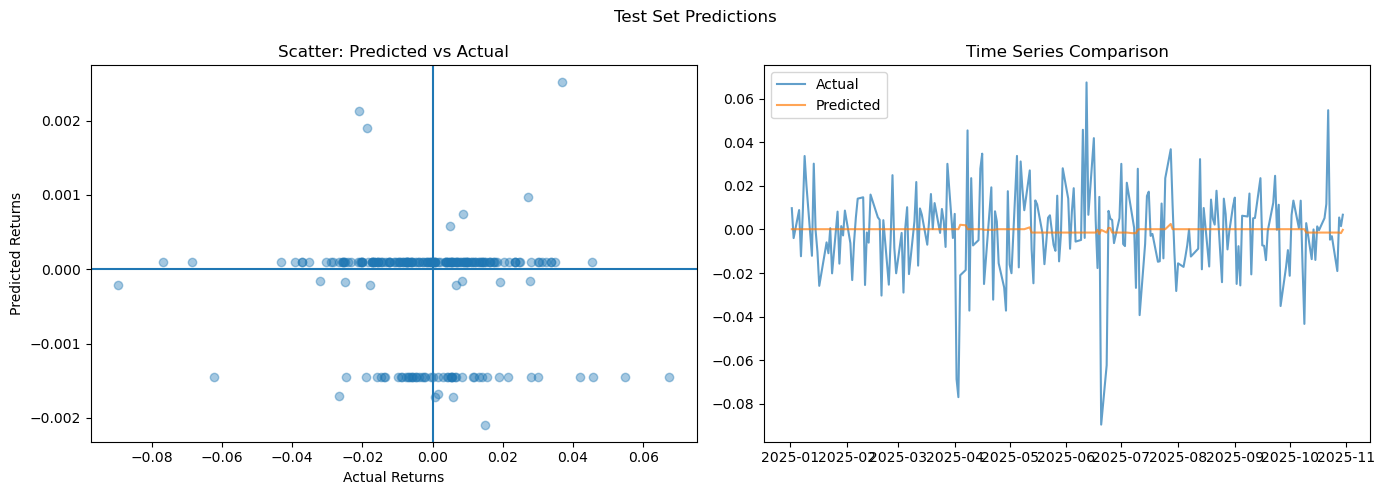

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_pred_vs_actual(model, X, y, title="Predicted vs Actual Returns"):
    """
    Scatter plot and time series comparison of predicted vs actual returns.
    """

    preds = model.predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -----------------------------
    # Scatter plot
    # -----------------------------
    axes[0].scatter(y, preds, alpha=0.4)
    axes[0].axhline(0)
    axes[0].axvline(0)
    axes[0].set_xlabel("Actual Returns")
    axes[0].set_ylabel("Predicted Returns")
    axes[0].set_title("Scatter: Predicted vs Actual")

    # -----------------------------
    # Time series comparison
    # -----------------------------
    axes[1].plot(y.index, y.values, label="Actual", alpha=0.7)
    axes[1].plot(y.index, preds, label="Predicted", alpha=0.7)
    axes[1].set_title("Time Series Comparison")
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_pred_vs_actual(model, Xte, yte, title="Test Set Predictions")



In [12]:
print("Prediction std:", np.std(model.predict(Xte)))
print("Actual std:", np.std(yte))

Prediction std: 0.00074707286
Actual std: 0.02050291075997622


## Cumulative Return Comparison (Economic Interpretation)
This plot compares cumulative buy-and-hold returns to a simple strategy that goes long when the predicted return is positive and short when it is negative.

The strategy underperforms buy-and-hold over the test period. This is consistent with the slightly below 50% directional accuracy observed in the test metrics. When directional accuracy is close to or below random, sign-based trading compounds losses over time.

The result suggests that the model does not produce a reliable directional signal at the one-day horizon. This aligns with the earlier scatter plot, which showed predictions concentrated near zero, and with the low R² values.

Overall, the cumulative return plot confirms that the model does not generate economically meaningful trading signals under a naive sign-based strategy.

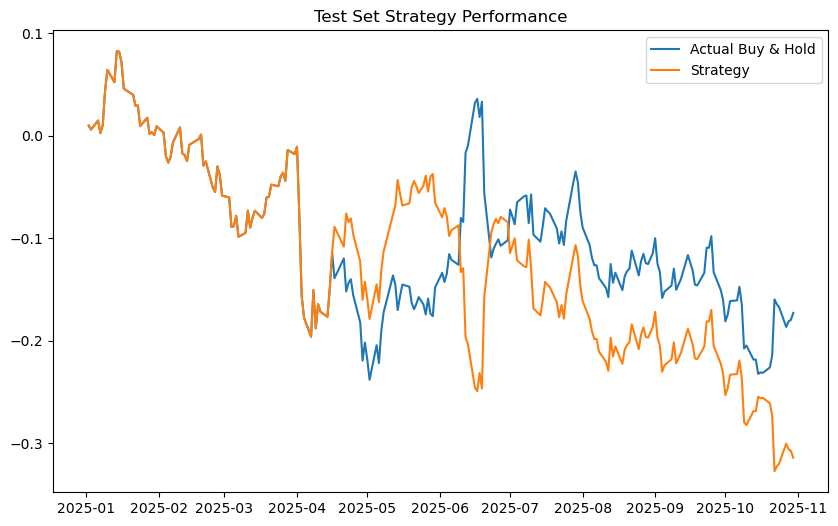

In [14]:
def plot_cumulative_returns(model, X, y, title="Cumulative Returns"):
    """
    Plot cumulative actual returns vs strategy returns
    based on predicted sign.
    """

    preds = model.predict(X)

    df = pd.DataFrame({
        "actual": y.values,
        "pred": preds
    }, index=y.index)

    # Strategy: long if predicted return > 0, short otherwise
    df["strategy"] = np.sign(df["pred"]) * df["actual"]

    df["actual_cum"] = df["actual"].cumsum()
    df["strategy_cum"] = df["strategy"].cumsum()

    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df["actual_cum"], label="Actual Buy & Hold")
    plt.plot(df.index, df["strategy_cum"], label="Strategy")
    plt.title(title)
    plt.legend()
    plt.show()
plot_cumulative_returns(model, Xte, yte, title="Test Set Strategy Performance")


## Training vs Validation Loss Curve
This plot shows the evolution of training and validation RMSE across boosting rounds.

Training RMSE steadily declines, indicating that the model is successfully fitting structure in the training data. However, validation RMSE remains nearly flat and does not improve meaningfully as additional trees are added.

This suggests that while the model is able to fit training patterns, those patterns do not generalize strongly to unseen data. Early stopping activates around 60 boosting rounds, preventing overfitting.

The stable gap between training and validation error indicates mild overfitting but not severe divergence. More importantly, the flat validation curve suggests that the available macro features provide limited incremental predictive signal at the one-day horizon.

This behavior is fully consistent with:

- Near-zero R²
- Weak directional accuracy
- Conservative predictions

The model extracts weak signal quickly and then plateaus.

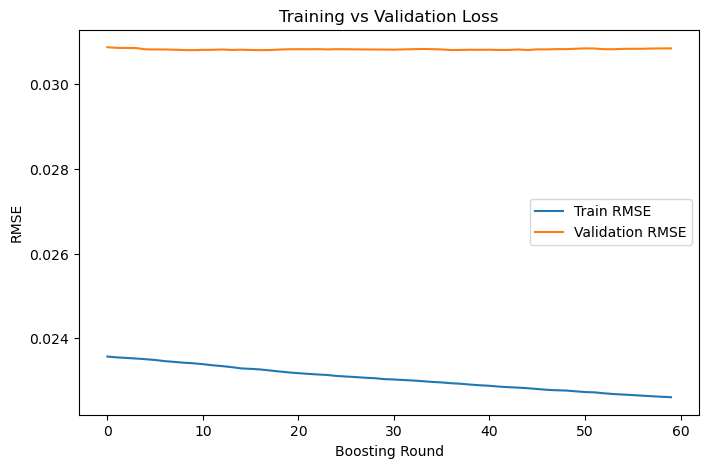

In [23]:
def plot_training_loss(model):
    """
    Plot training and validation RMSE across boosting rounds.
    """

    results = model.eval_results_

    train_rmse = results["validation_0"]["rmse"]
    val_rmse = results["validation_1"]["rmse"]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.plot(train_rmse, label="Train RMSE")
    plt.plot(val_rmse, label="Validation RMSE")
    plt.xlabel("Boosting Round")
    plt.ylabel("RMSE")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()
plot_training_loss(model)


## Rolling RMSE
This plot shows the rolling 50-day RMSE over the test period.

RMSE increases significantly during the middle of the test period and then declines later. This indicates regime-dependent performance.

The spike in RMSE corresponds to a period where the model struggled to predict returns accurately. This likely reflects increased volatility or structural shifts in oil markets during that time. Since the model relies on macro variables, which evolve slowly, it performs poorly during sudden market shocks.

The later decline in RMSE suggests that when market conditions stabilize, the model performs slightly better relative to realized volatility.

This regime behavior aligns with the overall findings that macro variables have limited power in high-volatility short-term forecasting.

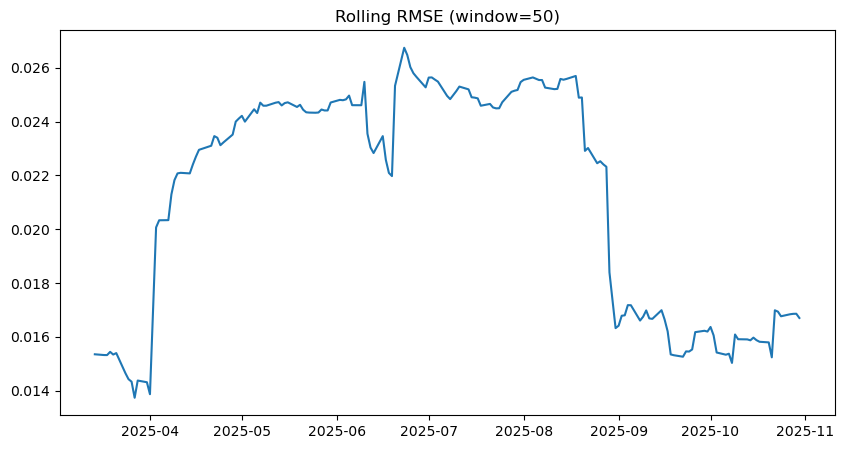

In [24]:
def plot_rolling_rmse(model, X, y, window=50):
    """
    Plot rolling RMSE over time.
    """

    preds = model.predict(X)

    df = pd.DataFrame({
        "actual": y.values,
        "pred": preds
    }, index=y.index)

    df["sq_error"] = (df["actual"] - df["pred"]) ** 2
    df["rolling_rmse"] = np.sqrt(df["sq_error"].rolling(window).mean())

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["rolling_rmse"])
    plt.title(f"Rolling RMSE (window={window})")
    plt.show()
plot_rolling_rmse(model, Xte, yte)


## Rolling Directional Accuracy
This plot shows rolling 50-day directional accuracy, with 0.5 marked as the random benchmark.

Directional accuracy fluctuates above and below 50%, indicating unstable predictive performance across regimes. During certain periods, accuracy rises to approximately 55%, suggesting temporary predictive structure. However, during the middle regime, accuracy collapses below 40%, indicating significant model failure during that period.

This pattern aligns directly with the rolling RMSE plot. When RMSE increases sharply, directional accuracy deteriorates. When RMSE stabilizes, directional accuracy improves slightly.

This confirms that the model's predictive ability is regime-dependent and weak overall. It performs marginally better in stable periods but fails during high-volatility or shock-driven environments.

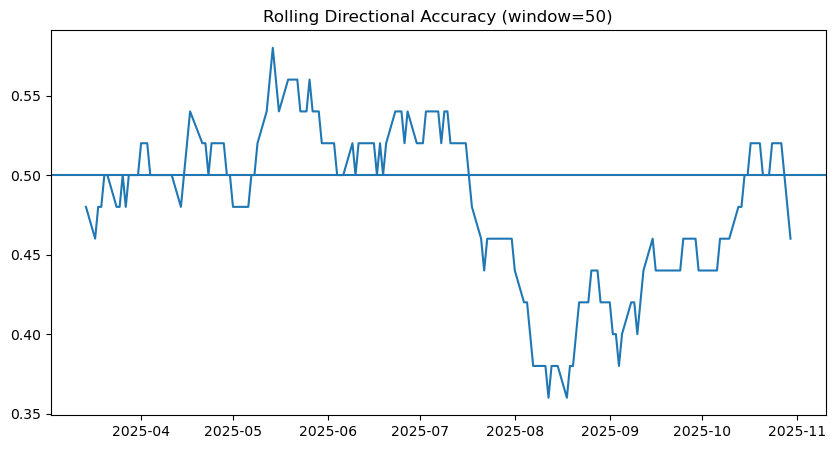

In [25]:
def plot_rolling_directional_accuracy(model, X, y, window=50):
    """
    Plot rolling directional accuracy over time.
    """

    preds = model.predict(X)

    df = pd.DataFrame({
        "actual": y.values,
        "pred": preds
    }, index=y.index)

    df["correct"] = (np.sign(df["actual"]) == np.sign(df["pred"])).astype(int)
    df["rolling_acc"] = df["correct"].rolling(window).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["rolling_acc"])
    plt.axhline(0.5)
    plt.title(f"Rolling Directional Accuracy (window={window})")
    plt.show()
plot_rolling_directional_accuracy(model, Xte, yte)


# Entire Code Block

In [3]:
# ============================================================
# XGBoost Forecasting for WTI Futures (Next-Day Log Returns)
# ============================================================
# - Uses FRED-MD macro data
# - Aligns macro to oil trading days only
# - No synthetic weekend rows
# - Strict anti-leakage macro shifting
# - 30-day lag window
# - TimeSeriesSplit CV (5 folds)
# - Early stopping
# ============================================================

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle

from abc import ABC, abstractmethod
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


# ============================================================
# Base Forecast Model
# ============================================================

class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X, y):
        pass

    @abstractmethod
    def save(self, path: str):
        pass

    @abstractmethod
    def load(self, path: str):
        pass


# ============================================================
# Metrics
# ============================================================

def rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))


# ============================================================
# Data Helpers (STRICT leakage control)
# ============================================================

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]

    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")

    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    s = px.set_index("Date")["Price"].sort_index()
    return s


def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1
    ).dropna()


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")


# ============================================================
# Trading-Day Aligned Dataset Builder
# ============================================================

def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):

    # Load macro monthly
    macro_m = load_macro_monthly(macro_file, features)

    # Shift month m -> becomes available at month m+1 (anti-leakage)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # Load oil prices (trading days only)
    price = load_price(price_file)

    # Align macro strictly onto trading-day index
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Combine
    base = macro_d.join(price, how="inner").dropna()

    # Add daily return feature (uses past only)
    base["ret_1d"] = np.log(base["Price"]).diff()

    # Lag features
    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)

    X = X_macro.join(X_price).dropna()

    # Target
    y = make_target(base["Price"], horizon=horizon)

    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train = X.index <= train_end
    val = (X.index > train_end) & (X.index <= val_end)
    test = X.index > val_end

    return (
        X.loc[train], y.loc[train],
        X.loc[val],   y.loc[val],
        X.loc[test],  y.loc[test],
    )


# ============================================================
# XGBoost Model
# ============================================================

class XGBoostForecastModel(BaseForecastModel):

    def __init__(
        self,
        n_splits=5,
        num_boost_round=3000,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
    ):
        super().__init__("regression")

        self.n_splits = n_splits
        self.num_boost_round = num_boost_round
        self.early_stopping_rounds = early_stopping_rounds
        self.random_state = random_state
        self.n_jobs = n_jobs

        self.param_grid = [
            {"max_depth": 3, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1},
            {"max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1},
            {"max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
        ]

        self.model = None
        self.best_params_ = None
        self.cv_results_ = []
        self.feature_names_ = None


    def fit(self, X_train, y_train, X_val=None, y_val=None):

        self.feature_names_ = list(X_train.columns)

        X = X_train.values
        y = y_train.values

        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        best_rmse = np.inf
        best_params = None

        # ---------------------------
        # Cross-validation grid search
        # ---------------------------
        for params in self.param_grid:

            fold_rmses = []

            for tr_idx, va_idx in tscv.split(X):

                Xtr, Xva = X[tr_idx], X[va_idx]
                ytr, yva = y[tr_idx], y[va_idx]

                model = XGBRegressor(
                    objective="reg:squarederror",
                    n_estimators=self.num_boost_round,
                    tree_method="hist",
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    early_stopping_rounds=self.early_stopping_rounds,  # <-- FIX
                    **params
                )

                model.fit(
                    Xtr, ytr,
                    eval_set=[(Xva, yva)],
                    verbose=False
                )

                preds = model.predict(Xva)
                fold_rmses.append(rmse(yva, preds))

            mean_rmse = np.mean(fold_rmses)

            self.cv_results_.append({
                "params": params,
                "rmse": mean_rmse
            })

            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_params = params

        self.best_params_ = {**best_params, "cv_rmse": best_rmse}

        # ---------------------------
        # Final Model Training
        # ---------------------------
        self.model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=self.num_boost_round,
            tree_method="hist",
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            early_stopping_rounds=self.early_stopping_rounds,  # <-- FIX
            **best_params
        )

        if X_val is not None and y_val is not None:
            self.model.fit(
                X_train.values, y_train.values,
                eval_set=[(X_val.values, y_val.values)],
                verbose=False
            )
        else:
            self.model.fit(X_train.values, y_train.values)

        return self


    def predict(self, X):
        return self.model.predict(X.values)


    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y.values, p),
            "mae": mae(y.values, p),
            "r2": r2(y.values, p),
            "directional_acc": directional_accuracy(y.values, p),
        }


    def feature_importance(self, top_n=20):

        booster = self.model.get_booster()
        score = booster.get_score(importance_type="gain")

        # Map f0 → actual feature name
        mapped = {}
        for k, v in score.items():
            idx = int(k.replace("f", ""))
            mapped[self.feature_names_[idx]] = v

        df = pd.DataFrame({
            "feature": list(mapped.keys()),
            "importance": list(mapped.values())
        }).sort_values("importance", ascending=False)

        return df.head(top_n).reset_index(drop=True)


    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))



# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30,
        horizon=1,
        train_end="2014-12-31",
        val_end="2024-12-31",
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    model = XGBoostForecastModel()
    model.fit(Xtr, ytr, X_val=Xva, y_val=yva)

    print("\nBest params:", model.best_params_)
    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))

    print("\nTop Features:")
    print(model.feature_importance())

    model.save("xgboost_wti_30d.pkl")


Shapes: (7953, 960) (2635, 960) (215, 960)

Best params: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'cv_rmse': np.float64(0.023563471050765124)}

Validation: {'rmse': 0.030803280416137484, 'mae': 0.018459234674905615, 'r2': 0.004345955878446661, 'directional_acc': 0.5328273244781784}

Test: {'rmse': 0.02058261496475133, 'mae': 0.015205284757750105, 'r2': -0.00779002836083853, 'directional_acc': 0.4744186046511628}

Top Features:
           feature  importance
0    EXUSUKx_lag22    0.064525
1        BAA_lag12    0.063394
2     T1YFFM_lag24    0.057851
3    EXUSUKx_lag23    0.055624
4    EXUSUKx_lag15    0.053068
5    EXUSUKx_lag12    0.049998
6     T1YFFM_lag25    0.048506
7    EXUSUKx_lag13    0.037498
8     ret_1d_lag09    0.033128
9     T1YFFM_lag16    0.030246
10    ret_1d_lag27    0.029952
11    T1YFFM_lag15    0.028379
12   IPFPNSS_lag02    0.027727
13    BAAFFM_lag19    0.024219
14  USWTRADE_lag01    0.023923
15    PP